# Lab 01 — Không Gian Màu (Color Spaces) trong Computer Vision

Bài thực hành tìm hiểu và thao tác trực tiếp với các không gian màu thông dụng trong xử lý ảnh và thị giác máy tính: **BGR**, **RGB**, **Grayscale**, **HSV**, và **LAB**.

---

## 🎯 Mục tiêu bài học:
1. **Thứ tự kênh màu & Khác biệt thư viện:** Hiểu cơ chế biểu diễn BGR của OpenCV và RGB của Matplotlib/Pillow.
2. **Ảnh mức xám (Grayscale):** Chuyển đổi và phân tích cấu trúc ma trận (2D vs 3D), giảm tải tính toán, quan sát biểu đồ Histogram.
3. **Tách & trực quan hóa từng kênh màu:** Tách độc lập các kênh (R-G-B, H-S-V, L-a-b) để hiểu đóng góp của từng kênh.
4. **Không gian màu HSV & Phân đoạn màu:** Tách biệt thông tin màu sắc khỏi cường độ ánh sáng, ứng dụng lọc dải màu (Color Segmentation / Masking).
5. **Không gian màu LAB & Cân bằng sáng:** Khám phá đặc tính độc lập của kênh Lightness (L), ứng dụng cân bằng tương phản (CLAHE) mà không làm biến dạng màu sắc của ảnh.
6. **Lưu trữ kết quả:** Xuất các ảnh kết quả sau xử lý ra thư mục `data/output/`.


In [1]:
import os
import sys
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cấu hình đường dẫn linh hoạt (hỗ trợ chạy từ root repo hoặc thư mục lab_1/notebook)
cwd = Path.cwd().resolve()
if (cwd / "data" / "input").exists():
    LAB1_DIR = cwd
elif (cwd / "lab_1" / "data" / "input").exists():
    LAB1_DIR = cwd / "lab_1"
elif (cwd.parent / "data" / "input").exists():
    LAB1_DIR = cwd.parent
else:
    candidates = [p for p in [cwd] + list(cwd.parents) if (p / "lab_1" / "data" / "input").exists()]
    LAB1_DIR = candidates[0] / "lab_1" if candidates else cwd

INPUT_DIR = LAB1_DIR / "data" / "input"
OUTPUT_DIR = LAB1_DIR / "data" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2. Hàm đọc/ghi ảnh an toàn với đường dẫn tiếng Việt trên Windows
def read_image_bgr(path):
    """Đọc ảnh bằng np.fromfile + cv2.imdecode để tránh lỗi đường dẫn chứa tiếng Việt trên Windows."""
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"Không tìm thấy file: {path}")
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Không thể giải mã ảnh: {path}")
    return img

def save_image(path, img):
    """Lưu ảnh bằng cv2.imencode để an toàn với đường dẫn có dấu tiếng Việt."""
    path = Path(path)
    ext = path.suffix if path.suffix else ".png"
    success, buffer = cv2.imencode(ext, img)
    if not success:
        raise OSError(f"Lỗi khi mã hóa ảnh để lưu: {path}")
    with open(path, "wb") as f:
        f.write(buffer)
    return True

print(f"Thư mục làm việc LAB1 : {LAB1_DIR.name}")
print(f"Thư mục ảnh đầu vào   : {INPUT_DIR.name} ({len(list(INPUT_DIR.glob('*.*')))} files)")
print(f"Thư mục ảnh đầu ra    : {OUTPUT_DIR.name}")
print(f"OpenCV version        : {cv2.__version__}")
print(f"NumPy version         : {np.__version__}")


Thư mục làm việc LAB1 : lab_1
Thư mục ảnh đầu vào   : input (101 files)
Thư mục ảnh đầu ra    : output
OpenCV version        : 5.0.0
NumPy version         : 2.5.3


---
## 1. Đọc ảnh và sự khác biệt giữa BGR và RGB

- **OpenCV** mặc định đọc và xử lý ảnh theo thứ tự kênh **BGR (Blue - Green - Red)** (do yếu tố lịch sử từ phần cứng camera ban đầu).
- **Matplotlib** hiển thị ảnh theo chuẩn **RGB (Red - Green - Blue)**.
- Nếu truyền trực tiếp mảng BGR vào `plt.imshow()`, kênh Đỏ và Xanh dương sẽ bị tráo đổi, khiến ảnh hiển thị sai màu hoàn toàn (da người bị ám xanh tái, trang phục đỏ chuyển thành xanh dương).
- Hàm chuyển đổi chuẩn: `cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)`.


Tên file  : 02_portrait_astronaut.jpg
Shape     : (512, 512, 3)  # (Chiều cao H, Chiều rộng W, Số kênh C)
Dtype     : uint8
Min / Max : 0 / 255


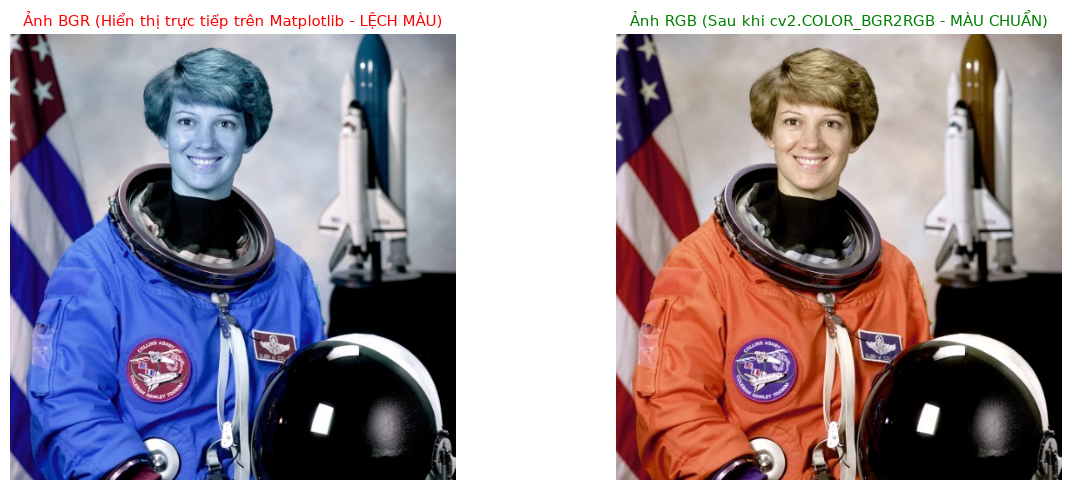

In [2]:
# 1. Đọc ảnh mẫu chân dung astronaut bằng OpenCV
sample_path = INPUT_DIR / "02_portrait_astronaut.jpg"
if not sample_path.exists():
    sample_path = INPUT_DIR / "01_portrait_grace_hopper.jpg"

img_bgr = read_image_bgr(sample_path)

# 2. Chuyển đổi sang định dạng RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Tên file  : {sample_path.name}")
print(f"Shape     : {img_bgr.shape}  # (Chiều cao H, Chiều rộng W, Số kênh C)")
print(f"Dtype     : {img_bgr.dtype}")
print(f"Min / Max : {img_bgr.min()} / {img_bgr.max()}")

# 3. So sánh trực quan trên Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(img_bgr)
axes[0].set_title("Ảnh BGR (Hiển thị trực tiếp trên Matplotlib - LỆCH MÀU)", fontsize=11, color="red")
axes[0].axis("off")

axes[1].imshow(img_rgb)
axes[1].set_title("Ảnh RGB (Sau khi cv2.COLOR_BGR2RGB - MÀU CHUẨN)", fontsize=11, color="green")
axes[1].axis("off")

plt.tight_layout()
plt.show()


---
## 2. Tách và quan sát các kênh màu Red, Green, Blue

Mỗi pixel trong ảnh RGB được tạo bởi sự pha trộn của 3 màu:
1. **Red (Đỏ):** Kênh `img_rgb[:, :, 0]`
2. **Green (Xanh lá):** Kênh `img_rgb[:, :, 1]`
3. **Blue (Xanh dương):** Kênh `img_rgb[:, :, 2]`

Dưới đây ta sẽ tách 3 kênh và hiển thị dưới 2 góc nhìn:
- **Ảnh mức xám (Grayscale intensity):** Điểm ảnh càng sáng nghĩa là kênh màu đó có cường độ càng lớn tại vị trí đó.
- **Ảnh màu tương ứng:** Giữ lại kênh đó và đặt 2 kênh còn lại về 0.


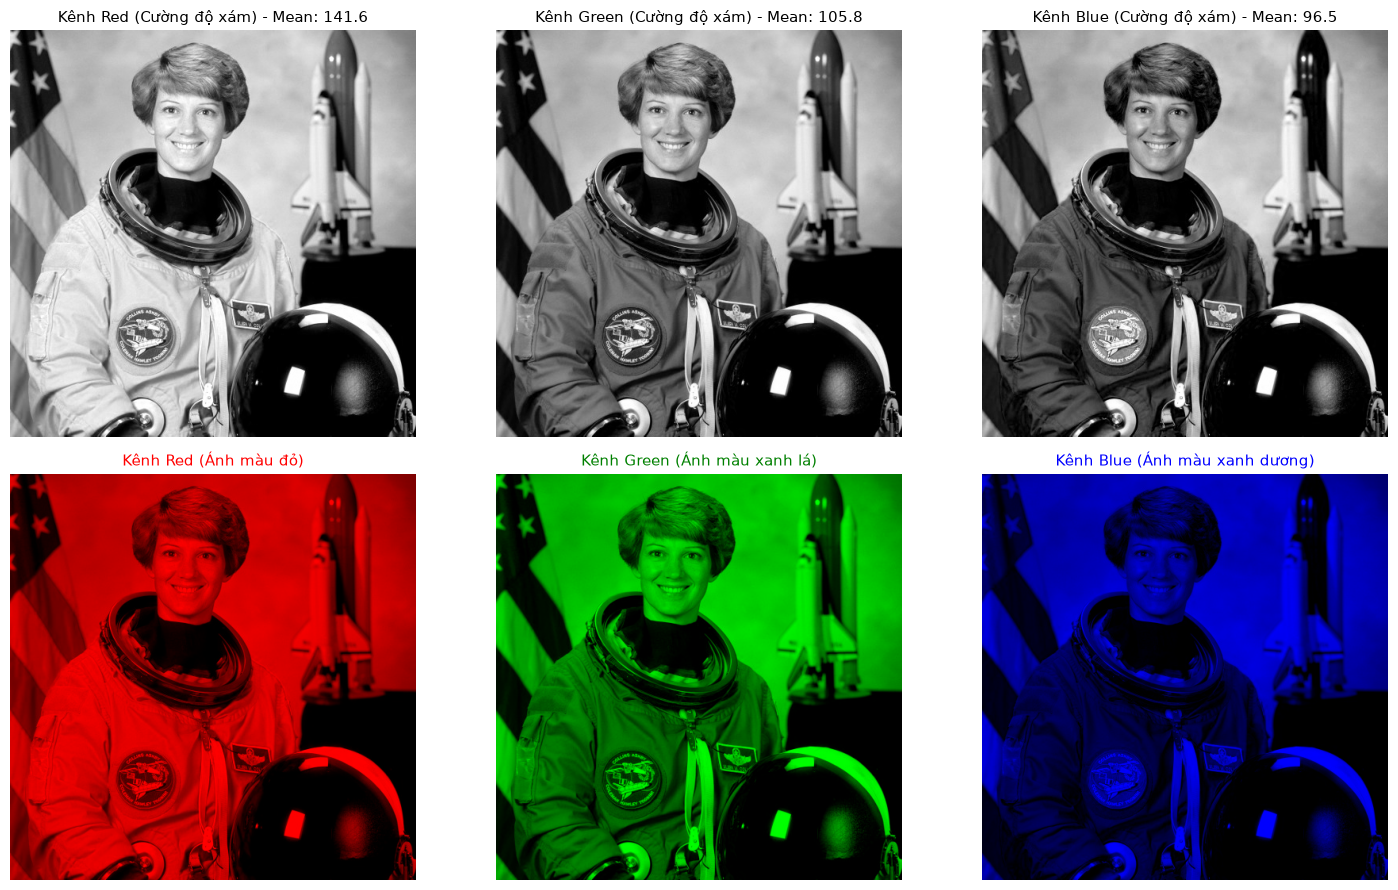

In [3]:
# Tách các kênh màu
r_ch = img_rgb[:, :, 0]
g_ch = img_rgb[:, :, 1]
b_ch = img_rgb[:, :, 2]

# Tạo ảnh hiển thị màu tương ứng cho từng kênh
zeros = np.zeros_like(r_ch)
red_preview = np.stack([r_ch, zeros, zeros], axis=2)
green_preview = np.stack([zeros, g_ch, zeros], axis=2)
blue_preview = np.stack([zeros, zeros, b_ch], axis=2)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Hàng 1: Hiển thị mức cường độ xám
axes[0, 0].imshow(r_ch, cmap="gray")
axes[0, 0].set_title(f"Kênh Red (Cường độ xám) - Mean: {r_ch.mean():.1f}", fontsize=11)
axes[0, 0].axis("off")

axes[0, 1].imshow(g_ch, cmap="gray")
axes[0, 1].set_title(f"Kênh Green (Cường độ xám) - Mean: {g_ch.mean():.1f}", fontsize=11)
axes[0, 1].axis("off")

axes[0, 2].imshow(b_ch, cmap="gray")
axes[0, 2].set_title(f"Kênh Blue (Cường độ xám) - Mean: {b_ch.mean():.1f}", fontsize=11)
axes[0, 2].axis("off")

# Hàng 2: Hiển thị ánh màu tương ứng
axes[1, 0].imshow(red_preview)
axes[1, 0].set_title("Kênh Red (Ánh màu đỏ)", fontsize=11, color="red")
axes[1, 0].axis("off")

axes[1, 1].imshow(green_preview)
axes[1, 1].set_title("Kênh Green (Ánh màu xanh lá)", fontsize=11, color="green")
axes[1, 1].axis("off")

axes[1, 2].imshow(blue_preview)
axes[1, 2].set_title("Kênh Blue (Ánh màu xanh dương)", fontsize=11, color="blue")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


---
## 3. Không gian màu Grayscale (Ảnh mức xám)

- Công thức chuyển đổi chuẩn trong OpenCV (`cv2.COLOR_BGR2GRAY` theo chuẩn ITU-R BT.601):
  $$Y = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$$
- Hệ số màu xanh lá ($0.587$) cao nhất vì mắt người nhạy cảm nhất với ánh sáng màu lục.
- Dữ liệu giảm từ ma trận 3 chiều $(H, W, 3)$ xuống ma trận 2 chiều $(H, W)$, tiết kiệm bộ nhớ và tăng tốc xử lý cho các thuật toán phát hiện cạnh, nhận diện đối tượng.


Đặc tính của ảnh Grayscale:
- Kích thước shape : (512, 512) (mảng 2 chiều)
- Kiểu dữ liệu     : uint8
- Giá trị Min / Max: 0 / 255
- Trung bình (Mean): 115.43


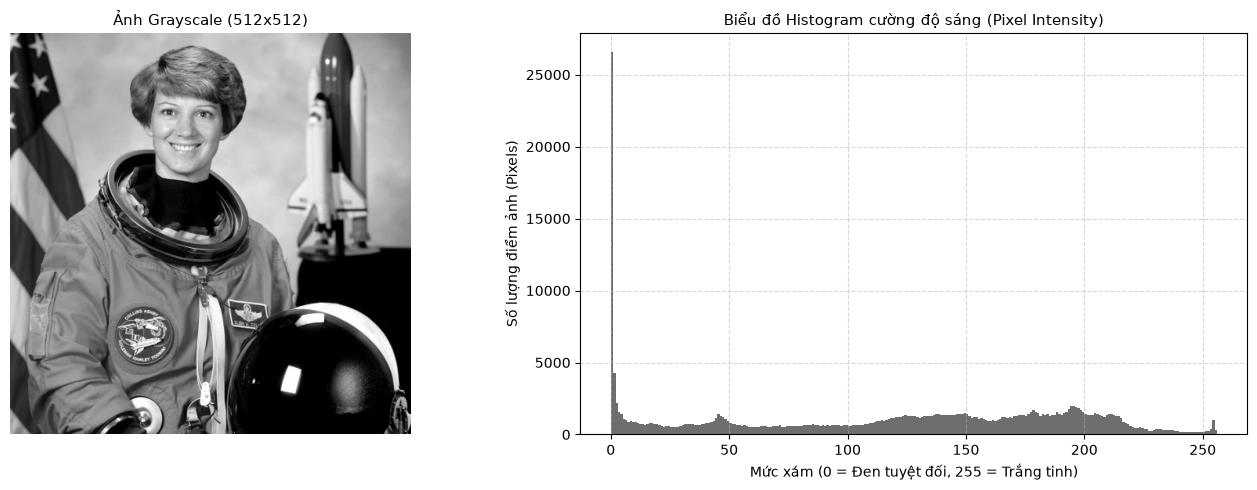

In [4]:
# Chuyển đổi sang Grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Đặc tính của ảnh Grayscale:")
print(f"- Kích thước shape : {img_gray.shape} (mảng 2 chiều)")
print(f"- Kiểu dữ liệu     : {img_gray.dtype}")
print(f"- Giá trị Min / Max: {img_gray.min()} / {img_gray.max()}")
print(f"- Trung bình (Mean): {img_gray.mean():.2f}")

# Vẽ ảnh mức xám và biểu đồ Histogram phân bố cường độ sáng
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title(f"Ảnh Grayscale ({img_gray.shape[1]}x{img_gray.shape[0]})", fontsize=11)
axes[0].axis("off")

axes[1].hist(img_gray.ravel(), bins=256, range=[0, 256], color="#555555", alpha=0.85)
axes[1].set_title("Biểu đồ Histogram cường độ sáng (Pixel Intensity)", fontsize=11)
axes[1].set_xlabel("Mức xám (0 = Đen tuyệt đối, 255 = Trắng tinh)")
axes[1].set_ylabel("Số lượng điểm ảnh (Pixels)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


---
## 4. Không gian màu HSV (Hue - Saturation - Value)

Không gian màu HSV phân tách thông tin thành 3 thành phần:
- **Hue (H - Sắc thái màu):** Xác định loại màu (đỏ, vàng, lục, lam, tím...). Trong OpenCV, góc $0^\circ - 360^\circ$ được chia đôi để vừa kiểu `uint8`: **$H \in [0, 179]$**.
- **Saturation (S - Độ bão hòa):** Độ tinh khiết của màu: **$S \in [0, 255]$** (0 là màu xám nhạt, 255 là màu thuần khiết nhất).
- **Value (V - Độ sáng):** Cường độ ánh sáng: **$V \in [0, 255]$** (0 là tối đen, 255 là sáng nhất).

👉 **Lợi thế lớn nhất:** Thông tin màu sắc ($H, S$) tách biệt hoàn toàn khỏi độ sáng ($V$). Khi ánh sáng môi trường thay đổi, giá trị $H$ gần như không đổi, rất hữu ích cho bài toán theo dõi vật thể (object tracking) và nhận diện màu sắc.


Khoảng giá trị thực tế trong ảnh:
- Hue        (H): [0, 179] (khoảng chuẩn OpenCV: 0-179)
- Saturation (S): [0, 255] (khoảng chuẩn: 0-255)
- Value      (V): [0, 255] (khoảng chuẩn: 0-255)


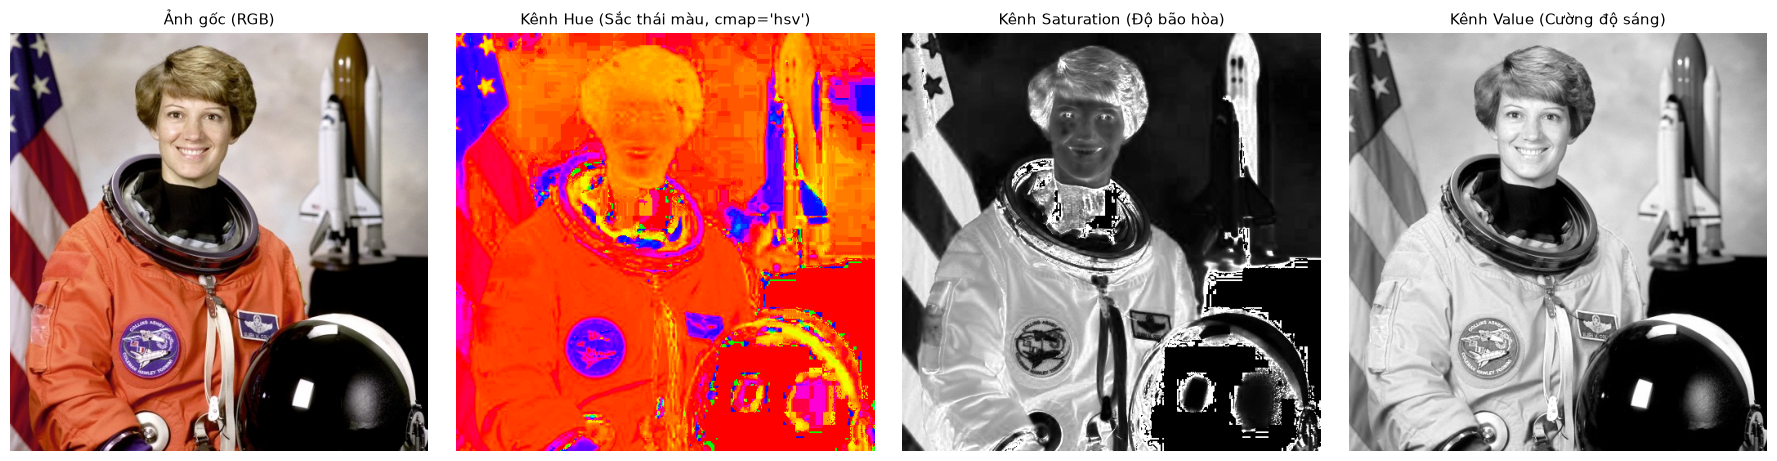

In [5]:
# Chuyển đổi sang HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h_ch, s_ch, v_ch = cv2.split(img_hsv)

print("Khoảng giá trị thực tế trong ảnh:")
print(f"- Hue        (H): [{h_ch.min()}, {h_ch.max()}] (khoảng chuẩn OpenCV: 0-179)")
print(f"- Saturation (S): [{s_ch.min()}, {s_ch.max()}] (khoảng chuẩn: 0-255)")
print(f"- Value      (V): [{v_ch.min()}, {v_ch.max()}] (khoảng chuẩn: 0-255)")

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(img_rgb)
axes[0].set_title("Ảnh gốc (RGB)", fontsize=11)
axes[0].axis("off")

axes[1].imshow(h_ch, cmap="hsv")
axes[1].set_title("Kênh Hue (Sắc thái màu, cmap='hsv')", fontsize=11)
axes[1].axis("off")

axes[2].imshow(s_ch, cmap="gray")
axes[2].set_title("Kênh Saturation (Độ bão hòa)", fontsize=11)
axes[2].axis("off")

axes[3].imshow(v_ch, cmap="gray")
axes[3].set_title("Kênh Value (Cường độ sáng)", fontsize=11)
axes[3].axis("off")

plt.tight_layout()
plt.show()


---
## 5. Ứng dụng HSV: Phân đoạn màu sắc (Color Segmentation / Masking)

Nhờ đặc tính của kênh **Hue**, ta có thể dễ dàng tách đối tượng có màu sắc mong muốn ra khỏi nền bằng cách:
1. Đặt ngưỡng cận dưới `lower_bound` và cận trên `upper_bound` trong không gian HSV.
2. Dùng hàm `cv2.inRange()` để tạo ra một mặt nạ nhị phân (**Binary Mask**): vùng chọn có giá trị 255 (trắng), vùng nền có giá trị 0 (đen).
3. Dùng toán tử `cv2.bitwise_and()` kết hợp ảnh gốc với mặt nạ để giữ lại riêng đối tượng.


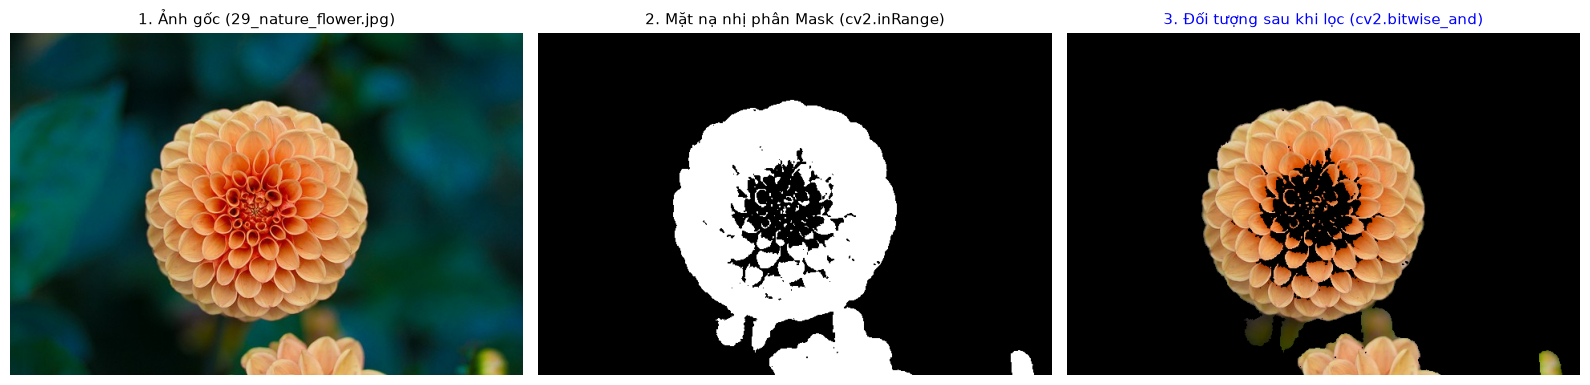

In [6]:
# Thử nghiệm trên ảnh hoa thiên nhiên (nhiều màu sắc sinh động)
flower_path = INPUT_DIR / "29_nature_flower.jpg"
if not flower_path.exists():
    flower_path = sample_path

demo_bgr = read_image_bgr(flower_path)
demo_rgb = cv2.cvtColor(demo_bgr, cv2.COLOR_BGR2RGB)
demo_hsv = cv2.cvtColor(demo_bgr, cv2.COLOR_BGR2HSV)

# Xác định ngưỡng lọc dải màu ấm (đỏ / cam / vàng của hoa)
# Trong OpenCV: H vàng/cam khoảng [10, 35], S >= 40, V >= 40
lower_hsv = np.array([10, 40, 40], dtype=np.uint8)
upper_hsv = np.array([35, 255, 255], dtype=np.uint8)

# Tạo mặt nạ nhị phân
mask = cv2.inRange(demo_hsv, lower_hsv, upper_hsv)

# Áp dụng mặt nạ lên ảnh gốc
segmented_bgr = cv2.bitwise_and(demo_bgr, demo_bgr, mask=mask)
segmented_rgb = cv2.cvtColor(segmented_bgr, cv2.COLOR_BGR2RGB)

# Hiển thị quy trình 3 bước
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(demo_rgb)
axes[0].set_title(f"1. Ảnh gốc ({flower_path.name})", fontsize=11)
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("2. Mặt nạ nhị phân Mask (cv2.inRange)", fontsize=11)
axes[1].axis("off")

axes[2].imshow(segmented_rgb)
axes[2].set_title("3. Đối tượng sau khi lọc (cv2.bitwise_and)", fontsize=11, color="blue")
axes[2].axis("off")

plt.tight_layout()
plt.show()


---
## 6. Không gian màu LAB (CIE L*a*b*)

Không gian màu LAB mô phỏng theo cảm nhận thị giác của mắt người:
- **L (Lightness):** Độ sáng từ $0$ (đen) đến $255$ (trắng trong OpenCV).
- **a:** Trục màu từ xanh lá cây (Green) đến đỏ tía (Magenta).
- **b:** Trục màu từ xanh dương (Blue) đến vàng (Yellow).

👉 **Ứng dụng đặc biệt - Cân bằng sáng (Histogram Equalization):**
- Trong không gian RGB, nếu ta cân bằng sáng từng kênh R, G, B thì màu sắc của ảnh sẽ bị sai lệch (bị ám màu lạ).
- Nhưng trong không gian LAB, ta chỉ cần cân bằng sáng trên **kênh L**, kênh $a$ và $b$ giữ nguyên. Kết quả là ảnh được cải thiện độ tương phản rõ rệt mà **màu sắc vẫn tự nhiên, không bị đổi màu**!


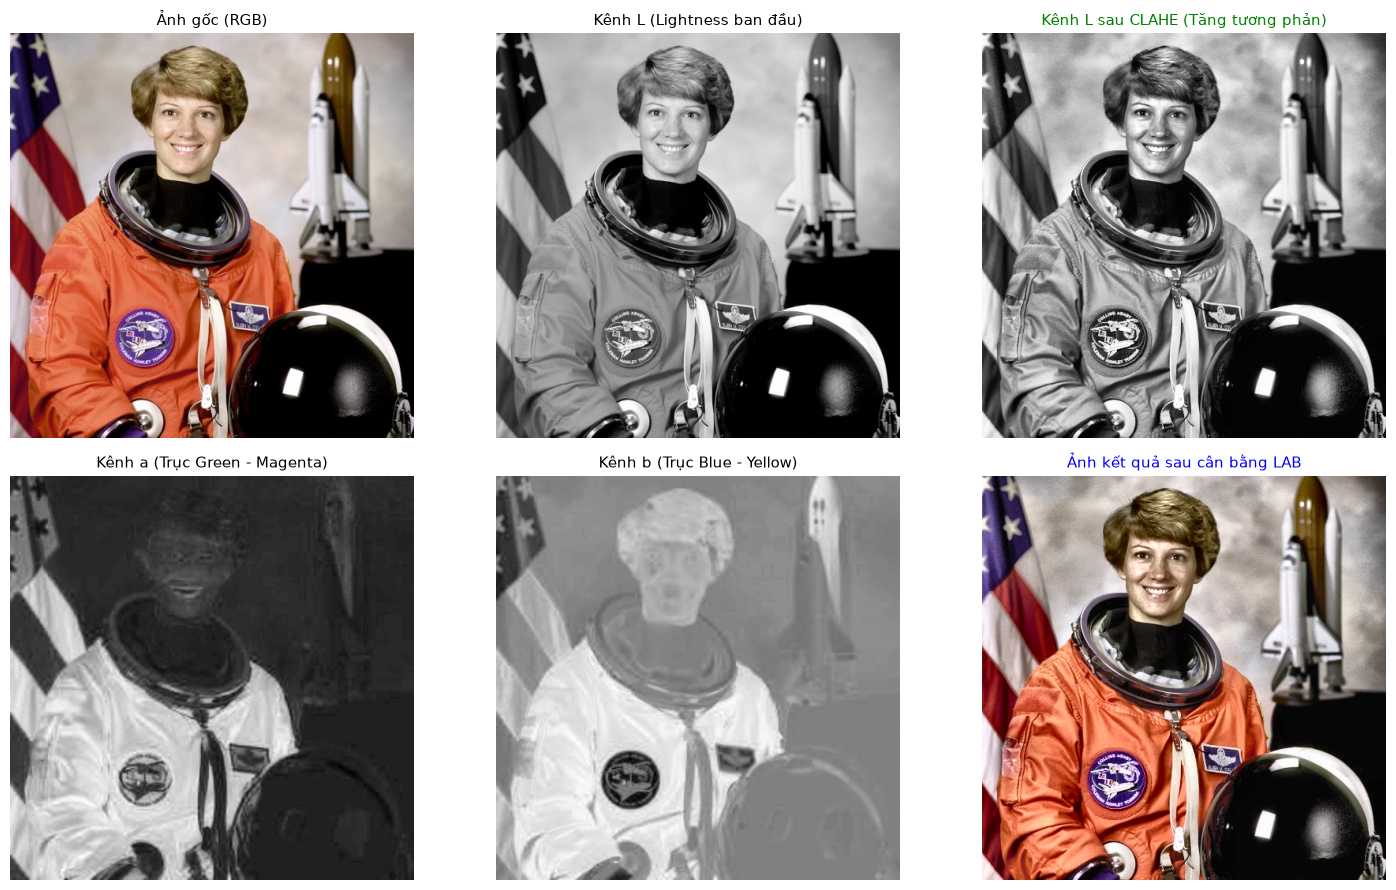

In [7]:
# 1. Chuyển đổi sang LAB
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
l_ch, a_ch, b_ch = cv2.split(img_lab)

# 2. Áp dụng thuật toán cân bằng tương phản thích ứng CLAHE trên kênh L
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
l_enhanced = clahe.apply(l_ch)

# 3. Hợp nhất lại kênh L đã tăng cường với kênh a, b nguyên bản
lab_enhanced = cv2.merge([l_enhanced, a_ch, b_ch])
enhanced_bgr = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)
enhanced_rgb = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Ảnh gốc (RGB)", fontsize=11)
axes[0, 0].axis("off")

axes[0, 1].imshow(l_ch, cmap="gray")
axes[0, 1].set_title("Kênh L (Lightness ban đầu)", fontsize=11)
axes[0, 1].axis("off")

axes[0, 2].imshow(l_enhanced, cmap="gray")
axes[0, 2].set_title("Kênh L sau CLAHE (Tăng tương phản)", fontsize=11, color="green")
axes[0, 2].axis("off")

axes[1, 0].imshow(a_ch, cmap="gray")
axes[1, 0].set_title("Kênh a (Trục Green - Magenta)", fontsize=11)
axes[1, 0].axis("off")

axes[1, 1].imshow(b_ch, cmap="gray")
axes[1, 1].set_title("Kênh b (Trục Blue - Yellow)", fontsize=11)
axes[1, 1].axis("off")

axes[1, 2].imshow(enhanced_rgb)
axes[1, 2].set_title("Ảnh kết quả sau cân bằng LAB", fontsize=11, color="blue")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()


---
## 7. Lưu các kết quả vào thư mục `data/output/`


In [8]:
# Định nghĩa các đường dẫn file output
out_gray = OUTPUT_DIR / "02_astronaut_gray.png"
out_hsv = OUTPUT_DIR / "02_astronaut_hsv.png"
out_lab = OUTPUT_DIR / "02_astronaut_lab.png"
out_enhanced = OUTPUT_DIR / "02_astronaut_enhanced_lab.png"
out_mask = OUTPUT_DIR / "02_flower_segmented.png"

# Lưu ảnh bằng hàm save_image (an toàn tiếng Việt trên Windows)
save_image(out_gray, img_gray)
save_image(out_hsv, img_hsv)
save_image(out_lab, img_lab)
save_image(out_enhanced, enhanced_bgr)
save_image(out_mask, segmented_bgr)

print("Đã lưu thành công các file ảnh kết quả:")
for p in [out_gray, out_hsv, out_lab, out_enhanced, out_mask]:
    size_kb = p.stat().st_size / 1024
    print(f" - {p.name:<30} : {size_kb:>7.2f} KB")


Đã lưu thành công các file ảnh kết quả:
 - 02_astronaut_gray.png          :  148.24 KB
 - 02_astronaut_hsv.png           :  400.37 KB
 - 02_astronaut_lab.png           :  317.84 KB
 - 02_astronaut_enhanced_lab.png  :  489.00 KB
 - 02_flower_segmented.png        :  129.65 KB


---
## 8. Tổng kết & So sánh các không gian màu

| Không gian màu | Số kênh | Đặc điểm nổi bật | Khi nào nên sử dụng? |
| :--- | :---: | :--- | :--- |
| **RGB / BGR** | 3 | Tổ hợp 3 màu cơ bản Đỏ-Xanh lá-Xanh dương. Thông tin màu sắc và ánh sáng bị trộn lẫn nhau. | Dùng khi đọc/ghi file ảnh thông thường, hiển thị trên màn hình. |
| **Grayscale** | 1 | Thể hiện mức xám/độ sáng của từng pixel. Tiết kiệm 66% dung lượng bộ nhớ. | Tiền xử lý cho phát hiện cạnh (Canny, Sobel), trích xuất đặc trưng (SIFT, ORB), nhận diện khuôn mặt. |
| **HSV** | 3 | Tách biệt sắc thái màu (**Hue**) khỏi cường độ sáng (**Value**). | Phân đoạn theo màu (Color Segmentation), bám vết đối tượng theo màu sắc trong điều kiện ánh sáng biến đổi. |
| **LAB** | 3 | Mô phỏng thị giác người, tách độ sáng (**L**) và 2 trục màu đối lập (**a, b**). | Cân bằng sáng/tương phản (CLAHE/Equalization) mà không đổi màu, tính khoảng cách khác biệt màu sắc. |

---
**Hoàn thành bài thực hành Không gian màu (Lab 01 - Issue Color Space).**
